In [38]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from pyDOE import lhs

In [39]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

GPU: True


In [40]:
def random_fun(num):
    temp = torch.from_numpy(lb + (ub - lb) * lhs(2, num)).float()
    if use_gpu:
        temp = temp.cuda()
    return temp

In [41]:
def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data

In [42]:
class Net(nn.Module):
    def __init__(self, layers):
        super(Net, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a


In [43]:
class Net_attention(nn.Module):
    def __init__(self, layers):
        super(Net_attention, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.loss_function = nn.MSELoss(reduction='mean')
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        self.attention1 = nn.Linear(layers[0], layers[1])
        self.attention2 = nn.Linear(layers[0], layers[1])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)
        nn.init.xavier_normal_(self.attention1.weight.data, gain=1.0)
        nn.init.zeros_(self.attention1.bias.data)
        nn.init.xavier_normal_(self.attention2.weight.data, gain=1.0)
        nn.init.zeros_(self.attention2.bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        encoder_1 = self.activation(self.attention1(x))
        encoder_2 = self.activation(self.attention2(x))
        a = a * encoder_1 + (1 - a) * encoder_2
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
            a = a * encoder_1 + (1 - a) * encoder_2
        a = self.linear[-1](a)
        return a


In [ ]:
class Model:
    def __init__(self, net, x_bc,
                 u_bc,
                 x_ic,
                 u_ic, x_f_loss_fun,
                 x_test, x_test_exact
                 ):

        self.x_ic_s = None
        self.x_bc_s = None
        self.x_ict_s = None
        self.x_f_s = None
        self.s_collect = []

        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic

        self.x_f_N = None
        self.x_f_M = None

        self.x_f_loss_fun = x_f_loss_fun

        self.x_test = x_test
        self.x_test_exact = x_test_exact

        self.start_loss_collect = False
        self.x_label_loss_collect = []
        self.x_f_loss_collect = []
        self.x_test_estimate_collect = []

        self.iter_error_collect = []  # 存储[iter_num, error_value]


    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def likelihood_loss(self, loss_e, loss_ic, loss_bc, loss_u0t):
        loss = torch.exp(-self.x_f_s) * loss_e.detach() + self.x_f_s \
               + torch.exp(-self.x_ic_s) * loss_ic.detach() + self.x_ic_s \
               + torch.exp(-self.x_bc_s) * loss_bc.detach() + self.x_bc_s \
               + torch.exp(-self.x_ict_s) * loss_u0t.detach() + self.x_ict_s
        return loss

    def true_loss(self, loss_e, loss_ic, loss_bc, loss_u0t):
        return torch.exp(-self.x_f_s.detach()) * loss_e + torch.exp(-self.x_ic_s.detach()) * loss_ic + torch.exp(
            -self.x_bc_s.detach()) * loss_bc + torch.exp(
            -self.x_ict_s.detach()) * loss_u0t

    # computer backward loss
    def epoch_loss(self):
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation = torch.mean(self.x_f_loss_fun(x_f, self.train_U) ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        x = Variable(self.x_ic, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_u0t = torch.mean(u0_t ** 2)

        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])
        return loss_equation, loss_ic, loss_bc, loss_u0t

    # computer backward loss
    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation = torch.mean(self.x_f_loss_fun(x_f, self.train_U) ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        x = Variable(self.x_ic, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_u0t = torch.mean(u0_t ** 2)

        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])

        loss = self.true_loss(loss_equation, loss_ic, loss_bc, loss_u0t)
        loss.backward()
        self.net.iter += 1
        print('Iter:', self.net.iter, 'Loss:', loss.item())
        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        exact = self.x_test_exact.cpu().detach().numpy()
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error
    

    def run_baseline(self):
        optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
        self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                 max_iter=lbgfs_iter)
        pbar = trange(adam_iter, ncols=100)
        for i in pbar:
            optimizer_adam.zero_grad()
            loss_e, loss_ic, loss_bc, loss_u0t = self.epoch_loss()
            loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_u0t)
            loss.backward()
            optimizer_adam.step()
            self.net.iter += 1
            pbar.set_postfix({'Iter': self.net.iter,
                              'Loss': '{0:.2e}'.format(loss.item())
                              })


        print('Adam done!')
        self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
        print('LBGFS done!')

        error = self.evaluate()
        print('Test_L2error:', '{0:.2e}'.format(error))

    def run_AM(self):
        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc, loss_u0t = self.epoch_loss()
                loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_u0t)
                loss.backward()
                self.net.iter += 1
                optimizer_adam.step()
                pbar.set_postfix({'Iter': self.net.iter,
                                  'Loss': '{0:.2e}'.format(loss.item())
                                  })

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            if AM_type == 0:
                x_init = random_fun(100000)
                x_init_residual = abs(self.x_f_loss_fun(x_init, self.train_U))
                x_init_residual = x_init_residual.cpu().detach().numpy()
                err_eq = np.power(x_init_residual, AM_K) / np.power(x_init_residual, AM_K).mean()
                err_eq_normalized = (err_eq / sum(err_eq))[:, 0]
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=err_eq_normalized)
                self.x_f_M = x_init[X_ids]

            elif AM_type == 1:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_x1 = dx[:, [0]].squeeze()
                grad_x2 = dx[:, [1]].squeeze()
                dx = torch.sqrt(1 + grad_x1 ** 2 + grad_x2 ** 2).cpu().detach().numpy()
                err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]

    def run_AM_AW1(self):
        self.x_f_s = nn.Parameter(self.x_f_s, requires_grad=True)
        self.x_ic_s = nn.Parameter(self.x_ic_s, requires_grad=True)
        self.x_bc_s = nn.Parameter(self.x_bc_s, requires_grad=True)
        self.x_ict_s = nn.Parameter(self.x_ict_s, requires_grad=True)

        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            optimizer_adam_weight = torch.optim.Adam([self.x_f_s] + [self.x_ic_s] + [self.x_bc_s] + [self.x_ict_s],
                                                     lr=AW_lr)

            pbar = trange(adam_iter, ncols=100)
            for i in pbar:
                self.s_collect.append([self.net.iter, self.x_f_s.item(), self.x_ic_s.item(), self.x_bc_s.item(),self.x_ict_s.item()])

                loss_e, loss_ic, loss_bc, loss_u0t = self.epoch_loss()

                optimizer_adam.zero_grad()
                loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_u0t)
                loss.backward()
                optimizer_adam.step()
                self.net.iter += 1
                pbar.set_postfix({'Iter': self.net.iter,
                                  'Loss': '{0:.2e}'.format(loss.item())
                                  })

                optimizer_adam_weight.zero_grad()
                loss = self.likelihood_loss(loss_e, loss_ic, loss_bc, loss_u0t)
                loss.backward()
                optimizer_adam_weight.step()
                if self.net.iter % 100 == 0:  # 记录间隔可调
                    error = self.evaluate()
                    self.iter_error_collect.append([self.net.iter, error])

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            if AM_type == 0:
                x_init = random_fun(100000)
                x_init_residual = abs(self.x_f_loss_fun(x_init, self.train_U))
                x_init_residual = x_init_residual.cpu().detach().numpy()
                err_eq = np.power(x_init_residual, AM_K) / np.power(x_init_residual, AM_K).mean()
                err_eq_normalized = (err_eq / sum(err_eq))[:, 0]
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=err_eq_normalized)
                self.x_f_M = x_init[X_ids]

            elif AM_type == 1:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_x1 = dx[:, [0]].squeeze()
                grad_x2 = dx[:, [1]].squeeze()
                dx = 0.5 * (grad_x1 ** 2 + grad_x2 ** 2).cpu().detach().numpy()
                err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]

    def train(self):

        self.x_f_N = random_fun(N)
        self.x_f_M = random_fun(M)

        # self.x_f_s = is_cuda(-torch.log(torch.tensor(1.).float()))
        # self.x_label_s = is_cuda(
        #     -torch.log(torch.tensor(100.).float()))  # 0.5*torch.exp(-self.x_label_s.detach()) = 100

        self.x_f_s = is_cuda(torch.tensor(0.).float())
        self.x_ic_s = is_cuda(torch.tensor(0.).float())
        self.x_bc_s = is_cuda(torch.tensor(0.).float())
        self.x_ict_s = is_cuda(torch.tensor(0.).float())

        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AM()
        elif model_type == 2:
            self.run_AM_AW1()
        elapsed = time.time() - start_time
        print('Training time: %.2f' % elapsed)



In [45]:
def U_tt(x, t):
    return - 25 * torch.pi ** 2 * x * torch.cos(5 * torch.pi * t) + 6 * t * x ** 3


def U_xx(x, t):
    return 6 * x * t ** 3


def PDE_f1(x, t):
    return U_tt(x, t) + a * U_xx(x, t) + b * PDE_u(x, t) + c * PDE_u(x, t) ** k


def PDE_u(x, t):
    return x * torch.cos(5 * torch.pi * t) + (x * t) ** 3


def x_f_loss_fun(x, train_U):
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    u = train_U(x)
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)
    u_x = d[0][:, 1].unsqueeze(-1)
    u_tt = torch.autograd.grad(u_t, x, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, [0]]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, [1]]
    t = x[:, [0]]
    x1 = x[:, [1]]
    f = u_tt + a * u_xx + b * u + c * u ** k - (
        PDE_f1(x1, t)
    )
    return f

In [46]:
def calculate_energy_density(x, u, train_U=None):
    """
    计算Klein-Gordon方程的能量密度
    E = 0.5 * (u_t)^2 + 0.5 * (-a) * (u_x)^2 + 0.5 * b * u^2 + c/(k+1) * u^(k+1)
    """
    if train_U is not None:
        if not x.requires_grad:
            x = Variable(x, requires_grad=True)
        u = train_U(x)
    
    # 计算梯度
    grad = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = grad[:, 0].unsqueeze(-1)
    u_x = grad[:, 1].unsqueeze(-1)
    
    # 计算能量密度
    kinetic_energy = 0.5 * u_t**2  # 动能
    gradient_energy = 0.5 * (-a) * u_x**2  # 梯度能
    potential_energy = 0.5 * b * u**2 + c/(k+1) * u**(k+1)  # 势能
    
    energy_density = kinetic_energy + gradient_energy + potential_energy
    return energy_density


In [47]:
def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    TT, XX = np.meshgrid(t, x)
    e = np.reshape(u_test_np, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='viridis')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'Exact Solution', fontsize=20)
    plt.tight_layout()
    plt.show()

    e = np.reshape(predict_np, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='viridis')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'Predicted Solution', fontsize=20)
    plt.tight_layout()
    plt.show()


def draw_exact_points(points, N_points=None, show_exact=True):
    if show_exact:
        u_test_np = x_test_exact.cpu().detach().numpy()
        XX1, XX2 = np.meshgrid(t, x)
        e = np.reshape(u_test_np, (XX1.shape[0], XX1.shape[1]))
        plt.pcolor(XX1, XX2, e, shading='auto', cmap='jet')
        plt.colorbar()
        # plt.title(r'Exact $u(x,t)$')
    if N_points is not None:
        adds = N_points.cpu().detach().numpy()
        plt.plot(adds[:, [0]], adds[:, [1]], 'kx', markersize=4, clip_on=False)

    points = points.cpu().detach().numpy()
    plt.plot(points[:, [0]], points[:, [1]], 'rx', markersize=4)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.show()


def draw_residual():
    f = x_f_loss_fun(x_test, model.train_U)
    f = f.cpu().detach().numpy()
    XX1, XX2 = np.meshgrid(t, x)
    e = np.reshape(abs(f), (XX1.shape[0], XX1.shape[1]))
    plt.pcolor(XX1, XX2, e, shading='auto', cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title('$Residual$', fontsize=20)
    plt.tight_layout()
    # plt.savefig('KG_residual-WAM-AW.pdf')
    plt.show()


def draw_error():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test = x_test_exact.cpu().detach().numpy()
    XX1, XX2 = np.meshgrid(t, x)
    e = np.reshape(abs(predict_np - u_test), (XX1.shape[0], XX1.shape[1]))
    plt.pcolor(XX1, XX2, e, shading='auto', cmap='coolwarm')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title('Absolute Error', fontsize=20)
    plt.tight_layout()
    plt.show()


def draw_epoch_loss():
    x_label_loss_collect = np.array(model.x_label_loss_collect)
    x_f_loss_collect = np.array(model.x_f_loss_collect)
    plt.subplot(2, 1, 1)
    plt.yscale('log')
    plt.plot(x_label_loss_collect[:, 0], x_label_loss_collect[:, 1], 'b-', label='Label_loss')
    plt.xlabel('$Epoch$')
    plt.ylabel('$Loss$')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.yscale('log')
    plt.plot(x_f_loss_collect[:, 0], x_f_loss_collect[:, 1], 'r-', label='PDE_loss')
    plt.xlabel('$Epoch$')
    plt.ylabel('$Loss$')
    plt.legend()
    plt.show()


def draw_epoch_w():
    s_collect = np.array(model.s_collect)
    np.savetxt('s_WAM-AW.npy', s_collect)
    plt.rc('legend', fontsize=16)
    plt.yscale('log')
    plt.plot(s_collect[:, 0], np.exp(-s_collect[:, 1]), 'b-', label='$e^{-s_{r}}$')
    plt.plot(s_collect[:, 0], np.exp(-s_collect[:, 2]), 'r-', label='$e^{-s_{i}}$')
    plt.plot(s_collect[:, 0], np.exp(-s_collect[:, 3]), 'g-', label='$e^{-s_{b}}$')
    plt.plot(s_collect[:, 0], np.exp(-s_collect[:, 4]), 'y-', label='$e^{-s_{it}}$')
    plt.xlabel('$Iters$', fontsize=20)
    plt.ylabel('$\lambda$', fontsize=20)
    plt.legend()
    # plt.savefig('KG_S_WAM-AW.pdf', fontsize=20)
    plt.show()




def draw_some_t():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    TT, XX = np.meshgrid(t, x)
    u_pred = np.reshape(predict_np, (TT.shape[0], TT.shape[1]))
    u_test = np.reshape(u_test_np, (TT.shape[0], TT.shape[1]))
    gs1 = gridspec.GridSpec(2, 2)
    # gs1.update(top=0.9, bottom=0.1, left=0.1, right=0.9, wspace=0.8)
    ax = plt.subplot(gs1[0, 0])
    plt.rc('legend', fontsize=16)
    ax.plot(x, u_test.T[0, :], 'b-', linewidth=2, label='Exact')
    ax.plot(x, u_pred.T[0, :], 'r--', linewidth=2, label='Prediction')
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$u(x,t)$', fontsize=20)
    ax.set_title('$t = %.2f$' % (t[0]), fontsize=20)

    ax.set_xlim([-0.1, 1.1])
    ax.axis('square')

    ax = plt.subplot(gs1[0, 1])
    ax.plot(x, u_test.T[25, :], 'b-', linewidth=2, label='Exact')
    ax.plot(x, u_pred.T[25, :], 'r--', linewidth=2, label='Prediction')
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$u(x,t)$', fontsize=20)
    ax.set_xlim([-0.1, 1.1])
    ax.axis('square')
    ax.set_title('$t = %.2f$' % (t[25]), fontsize=20)

    ax = plt.subplot(gs1[1, 0])
    ax.plot(x, u_test.T[50, :], 'b-', linewidth=2, label='Exact')
    ax.plot(x, u_pred.T[50, :], 'r--', linewidth=2, label='Prediction')
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$u(x,t)$', fontsize=20)
    ax.set_xlim([-0.1, 1.1])
    ax.axis('square')
    ax.set_title('$t = %.2f$' % (t[50]), fontsize=20)

    ax = plt.subplot(gs1[1, 1])
    ax.plot(x, u_test.T[-1, :], 'b-', linewidth=2, label='Exact')
    ax.plot(x, u_pred.T[-1, :], 'r--', linewidth=2, label='Prediction')
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$u(x,t)$', fontsize=20)
    ax.axis('square')
    ax.set_xlim([-0.1, 1.1])
    ax.set_title('$t = %.2f$' % (t[-1]), fontsize=20)
    plt.tight_layout()
    # plt.savefig('KG_qie_WAM-AW.pdf')
    plt.show()

def draw_L2_error():
    # 提取存储的迭代误差数据
    error_data = np.array(model.iter_error_collect)

    # 转换数据格式
    iterations = error_data[:, 0].astype(int)        # 迭代次数
    error_values = error_data[:, 1].astype(float)   # 误差值

    # 创建画布
    plt.figure(figsize=(10, 6))

    # 绘制对数曲线
    plt.semilogy(iterations, error_values, 
                'b-', 
                linewidth=1.5,
                alpha=0.7)

    # 添加标注和网格
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("$L^2$ Error", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # 保存并显示
    plt.tight_layout()
    # plt.savefig('L2_error_per_iteration.pdf', dpi=300)
    plt.show()


<>:102: SyntaxWarning: invalid escape sequence '\l'
<>:102: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1771/3317291548.py:102: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda$', fontsize=20)


In [ ]:
def calculate_energy_conservation_error():
    """
    计算能量守恒相对误差：|E(t) - E(0)|/|E(0)|

    """
    # 存储每个时间点的总能量
    total_energies = np.zeros(len(t))
    
    # 计算每个时间点的总能量
    for i, t_val in enumerate(t):
        # 创建当前时间点的所有空间点
        x_slice = np.hstack([np.full((len(x), 1), t_val), x])
        x_slice_tensor = is_cuda(torch.from_numpy(x_slice).float())
        
        x_slice_var = Variable(x_slice_tensor, requires_grad=True)
        u_pred_var = model.predict_U(x_slice_var)
        energy_density = calculate_energy_density(x_slice_var, u_pred_var).cpu().detach().numpy()
        
        # 通过积分计算总能量
        total_energies[i] = np.trapz(energy_density.flatten(), x.flatten())
    
    # 获取初始能量
    initial_energy = total_energies[0]
    
    # 计算相对于初始能量的误差
    relative_errors = np.abs(total_energies - initial_energy) / np.abs(initial_energy)
    
    return total_energies, relative_errors

def draw_energy_conservation_error():
    """绘制能量守恒相对误差随时间的变化"""
    total_energies, relative_errors = calculate_energy_conservation_error()
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # 绘制总能量随时间的变化
    ax1.plot(t.flatten(), total_energies, 'b-', linewidth=2)
    ax1.set_xlabel('$t$', fontsize=14)
    ax1.set_ylabel('Total Energy', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 标记初始能量
    ax1.axhline(y=total_energies[0], color='r', linestyle='--', label='$H_0$')
    ax1.legend()
    
    # 绘制相对误差（对数尺度）
    ax2.semilogy(t.flatten(), relative_errors, 'g-', linewidth=2)
    ax2.set_xlabel('$t$', fontsize=14)
    ax2.set_ylabel('Relative Energy Error', fontsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return total_energies, relative_errors

def draw_energy_distribution_at_times(time_indices=[0, 25, 50, 75]):
    """绘制特定时间点的能量密度分布"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, t_idx in enumerate(time_indices):
        t_val = t[t_idx]
        
        # 创建当前时间点的所有空间点
        x_slice = np.hstack([np.full((len(x), 1), t_val), x])
        x_slice_tensor = is_cuda(torch.from_numpy(x_slice).float())
        
        # 计算预测解的能量密度
        x_slice_var = Variable(x_slice_tensor, requires_grad=True)
        u_pred_var = model.predict_U(x_slice_var)
        energy_density = calculate_energy_density(x_slice_var, u_pred_var).cpu().detach().numpy()
        
        # 绘制能量密度分布
        ax = axes[i]
        ax.plot(x, energy_density, 'b-', linewidth=2)
        ax.set_xlabel('$x$', fontsize=14)
        ax.set_ylabel('Energy Density', fontsize=14)
        ax.set_title(f'$t = {t_val[0]:.2f}$', fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # 如果是初始时间点，标记为参考
        if t_idx == 0:
            ax.set_title(f'$t = {t_val[0]:.2f}$', fontsize=16)
    
    plt.tight_layout()
    plt.show()

def draw_energy_density_evolution_heatmap():
    """绘制能量密度随时空的演化热图"""
    # 创建能量密度矩阵
    energy_density_matrix = np.zeros((len(x), len(t)))
    
    # 计算每个时空点的能量密度
    for i, t_val in enumerate(t):
        x_slice = np.hstack([np.full((len(x), 1), t_val), x])
        x_slice_tensor = is_cuda(torch.from_numpy(x_slice).float())
        
        # 计算预测解的能量密度
        x_slice_var = Variable(x_slice_tensor, requires_grad=True)
        u_pred_var = model.predict_U(x_slice_var)
        energy_density = calculate_energy_density(x_slice_var, u_pred_var).cpu().detach().numpy()
        
        energy_density_matrix[:, i] = energy_density.flatten()
    
    # 绘制热图
    plt.figure(figsize=(12, 8))
    TT, XX = np.meshgrid(t.flatten(), x.flatten())
    plt.pcolor(TT, XX, energy_density_matrix, cmap='viridis', shading='auto')
    plt.colorbar(label='Energy Density')
    plt.xlabel('$t$', fontsize=14)
    plt.ylabel('$x$', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return energy_density_matrix


def analyze_energy_components():
    """分析不同时间点能量的各个分量(动能、梯度能、势能)"""
    # 选择几个时间点进行分析
    time_indices = [0, 25, 50, 75]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, t_idx in enumerate(time_indices):
        t_val = t[t_idx]
        
        # 创建当前时间点的所有空间点
        x_slice = np.hstack([np.full((len(x), 1), t_val), x])
        x_slice_tensor = is_cuda(torch.from_numpy(x_slice).float())
        x_slice_var = Variable(x_slice_tensor, requires_grad=True)
        
        # 计算预测解
        u_pred_var = model.predict_U(x_slice_var)
        
        # 计算梯度
        grad = torch.autograd.grad(u_pred_var, x_slice_var, grad_outputs=torch.ones_like(u_pred_var), create_graph=True)[0]
        u_t = grad[:, 0].unsqueeze(-1)
        u_x = grad[:, 1].unsqueeze(-1)
        
        # 计算各能量分量
        kinetic_energy = 0.5 * u_t**2  # 动能
        gradient_energy = 0.5 * (-a) * u_x**2  # 梯度能
        potential_energy = 0.5 * b * u_pred_var**2 + c/(k+1) * u_pred_var**(k+1)  # 势能
        
        # 转换为numpy数组
        kinetic_energy = kinetic_energy.cpu().detach().numpy()
        gradient_energy = gradient_energy.cpu().detach().numpy()
        potential_energy = potential_energy.cpu().detach().numpy()
        total_energy = kinetic_energy + gradient_energy + potential_energy
        
        # 绘制各能量分量
        ax = axes[i]
        ax.plot(x, kinetic_energy, 'r-', linewidth=2, label='kinetic energy')
        ax.plot(x, gradient_energy, 'g-', linewidth=2, label='gradient energy')
        ax.plot(x, potential_energy, 'b-', linewidth=2, label='potential energy')
        ax.plot(x, total_energy, 'k--', linewidth=2, label='total energy')
        
        ax.set_xlabel('$x$', fontsize=14)
        ax.set_ylabel('Energy Density', fontsize=14)
        ax.set_title(f'$t = {t_val[0]:.2f}$', fontsize=16)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [49]:
if __name__ == '__main__':
    lb = np.array([0.0, 0.0])
    ub = np.array([1.0, 1.0])

    layers = [2, 20, 20, 20, 20, 1]
    net = is_cuda(Net(layers))

    N = 1500
    M = 500
    Nbc = 100
    Nic = 100

    adam_iter, lbgfs_iter = 5000, 50000
    adam_lr, lbgfs_lr = 0.001, 0.5

    model_type = 2  # 0:baseline  1:AM  2:AM_AW

    AM_type = 1  # 0:RAM  1:WAM
    AM_K = 1
    AM_count = 10

    AW_lr = 0.001

    # test data
    k = 3
    a = -1
    b = 0
    c = 1

    exact_u = lambda x: x[:, [1]] * np.cos(5 * np.pi * x[:, [0]]) + np.power(x[:, [1]] * x[:, [0]], 3)

    t = np.expand_dims(np.linspace(0, 1, 100), axis=1)
    x = np.expand_dims(np.linspace(0, 1, 100), axis=1)
    X1, X2 = np.meshgrid(t, x)

    x_test_np = np.concatenate((np.vstack(np.expand_dims(X1, axis=2)), np.vstack(np.expand_dims(X2, axis=2))), axis=-1)
    solution = exact_u(x_test_np)
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    x_test_exact = is_cuda(torch.from_numpy(solution).float())

    # ic bc data
    x_init = torch.from_numpy(x).float()
    x_initial = torch.cat((torch.zeros(Nic, 1), x_init), dim=1)
    x_boundary_left = torch.cat((torch.rand([Nbc, 1]), torch.full([Nbc, 1], 0)), dim=1)
    x_boundary_right = torch.cat((torch.rand([Nbc, 1]), torch.ones([Nbc, 1])), dim=1)

    x_initial_label = torch.from_numpy(exact_u(x_initial.numpy())).float()
    x_boundary_left_label = torch.from_numpy(exact_u(x_boundary_left.numpy())).float()
    x_boundary_right_label = torch.from_numpy(exact_u(x_boundary_right.numpy())).float()

    x_ic = is_cuda(x_initial)
    u_ic = is_cuda(x_initial_label)
    x_bc = is_cuda(torch.cat((x_boundary_left, x_boundary_right), dim=0))
    u_bc = is_cuda(torch.cat((x_boundary_left_label, x_boundary_right_label), dim=0))

    model = Model(
        net=net,
        x_bc=x_bc,
        u_bc=u_bc,
        x_ic=x_ic,
        u_ic=u_ic,
        x_f_loss_fun=x_f_loss_fun,
        x_test=x_test,
        x_test_exact=x_test_exact,
    )
    model.train()
    print(model.x_test_estimate_collect)

  0%|                                               | 0/5000 [00:00<?, ?it/s, Iter=1, Loss=9.97e+03]

100%|█████████████████████████████████| 5000/5000 [00:55<00:00, 89.83it/s, Iter=5000, Loss=8.40e-01]


Adam done!
Iter: 5001 Loss: 0.8396680355072021
Iter: 5002 Loss: 66.9237289428711
Iter: 5003 Loss: 17.44589614868164
Iter: 5004 Loss: 4.856164932250977
Iter: 5005 Loss: 1.830448865890503
Iter: 5006 Loss: 1.086163878440857
Iter: 5007 Loss: 0.901318371295929
Iter: 5008 Loss: 0.8552136421203613
Iter: 5009 Loss: 0.8436610102653503
Iter: 5010 Loss: 0.8407430648803711
Iter: 5011 Loss: 0.8399935364723206
Iter: 5012 Loss: 0.8397867679595947
Iter: 5013 Loss: 0.8397200703620911
Iter: 5014 Loss: 0.8396897912025452
Iter: 5015 Loss: 0.8396649360656738
Iter: 5016 Loss: 0.8396376371383667
Iter: 5017 Loss: 0.8396057486534119
Iter: 5018 Loss: 0.8395555019378662
Iter: 5019 Loss: 0.8394774794578552
Iter: 5020 Loss: 0.8393334746360779
Iter: 5021 Loss: 0.8390766978263855
Iter: 5022 Loss: 0.8386489748954773
Iter: 5023 Loss: 0.8379530906677246
Iter: 5024 Loss: 0.8368832468986511
Iter: 5025 Loss: 0.8354491591453552
Iter: 5026 Loss: 0.834356963634491
Iter: 5027 Loss: 0.832334578037262
Iter: 5028 Loss: 0.8301986

100%|████████████████████████████████| 5000/5000 [00:58<00:00, 85.81it/s, Iter=18815, Loss=1.05e-01]


Adam done!
Iter: 18816 Loss: 0.1048661395907402
Iter: 18817 Loss: 983.4835815429688
Iter: 18818 Loss: 247.48013305664062
Iter: 18819 Loss: 57.28204345703125
Iter: 18820 Loss: 14.25078296661377
Iter: 18821 Loss: 3.7548370361328125
Iter: 18822 Loss: 1.112056016921997
Iter: 18823 Loss: 0.4240201711654663
Iter: 18824 Loss: 0.23193718492984772
Iter: 18825 Loss: 0.1692594587802887
Iter: 18826 Loss: 0.14226610958576202
Iter: 18827 Loss: 0.1261528879404068
Iter: 18828 Loss: 0.11469554901123047
Iter: 18829 Loss: 0.10737137496471405
Iter: 18830 Loss: 0.104428231716156
Iter: 18831 Loss: 0.10343249142169952
Iter: 18832 Loss: 0.10307101160287857
Iter: 18833 Loss: 0.1029067113995552
Iter: 18834 Loss: 0.1028071865439415
Iter: 18835 Loss: 0.10274102538824081
Iter: 18836 Loss: 0.10269340127706528
Iter: 18837 Loss: 0.1026766374707222
Iter: 18838 Loss: 0.10265354812145233
Iter: 18839 Loss: 0.1026323139667511
Iter: 18840 Loss: 0.10261550545692444
Iter: 18841 Loss: 0.10260150581598282
Iter: 18842 Loss: 0.1

...

Adam done!
Iter: 61425 Loss: 0.020664123818278313
Iter: 61426 Loss: 3023.817626953125
Iter: 61427 Loss: 750.6788940429688
Iter: 61428 Loss: 193.8182373046875
Iter: 61429 Loss: 49.37504959106445
Iter: 61430 Loss: 12.514617919921875
Iter: 61431 Loss: 3.1762983798980713
Iter: 61432 Loss: 0.8220947980880737
Iter: 61433 Loss: 0.22861658036708832
Iter: 61434 Loss: 0.07813094556331635
Iter: 61435 Loss: 0.03913646563887596
Iter: 61436 Loss: 0.028459127992391586
Iter: 61437 Loss: 0.025052860379219055
Iter: 61438 Loss: 0.023611998185515404
Iter: 61439 Loss: 0.022734384983778
Iter: 61440 Loss: 0.022052941843867302
Iter: 61441 Loss: 0.02155655063688755
Iter: 61442 Loss: 0.021348627284169197
Iter: 61443 Loss: 0.021207241341471672
Iter: 61444 Loss: 0.021159548312425613
Iter: 61445 Loss: 0.021099776029586792
Iter: 61446 Loss: 0.021020546555519104
Iter: 61447 Loss: 0.0209223460406065
Iter: 61448 Loss: 0.020808042958378792
Iter: 61449 Loss: 0.0206918828189373
Iter: 61450 Loss: 0.02061644196510315
Iter:

100%|████████████████████████████████| 5000/5000 [00:57<00:00, 87.14it/s, Iter=68607, Loss=3.45e+00]


Adam done!
Iter: 68608 Loss: 1.3983697891235352
Iter: 68609 Loss: 3691.21533203125
Iter: 68610 Loss: 944.7979736328125
Iter: 68611 Loss: 206.19921875
Iter: 68612 Loss: 48.52491760253906
Iter: 68613 Loss: 12.013633728027344
Iter: 68614 Loss: 3.119370937347412
Iter: 68615 Loss: 0.8898385763168335
Iter: 68616 Loss: 0.31405094265937805
Iter: 68617 Loss: 0.15599589049816132
Iter: 68618 Loss: 0.1058151051402092
Iter: 68619 Loss: 0.08448182046413422
Iter: 68620 Loss: 0.07093965262174606
Iter: 68621 Loss: 0.05944375321269035
Iter: 68622 Loss: 0.0491829589009285
Iter: 68623 Loss: 0.040743257850408554
Iter: 68624 Loss: 0.03582964837551117
Iter: 68625 Loss: 0.03338388726115227
Iter: 68626 Loss: 0.032172415405511856
Iter: 68627 Loss: 0.03147348761558533
Iter: 68628 Loss: 0.030687881633639336
Iter: 68629 Loss: 0.029810387641191483
Iter: 68630 Loss: 0.028734790161252022
Iter: 68631 Loss: 0.027696043252944946
Iter: 68632 Loss: 0.02695605158805847
Iter: 68633 Loss: 0.0264446958899498
Iter: 68634 Loss:

100%|████████████████████████████████| 5000/5000 [00:58<00:00, 85.01it/s, Iter=75074, Loss=1.22e-01]


Adam done!
Iter: 75075 Loss: 0.23148927092552185
Iter: 75076 Loss: 3807.406005859375
Iter: 75077 Loss: 961.116455078125
Iter: 75078 Loss: 220.378662109375
Iter: 75079 Loss: 54.06038284301758
Iter: 75080 Loss: 13.977590560913086
Iter: 75081 Loss: 3.8951940536499023
Iter: 75082 Loss: 1.2610986232757568
Iter: 75083 Loss: 0.5219836831092834
Iter: 75084 Loss: 0.2802223563194275
Iter: 75085 Loss: 0.17620037496089935
Iter: 75086 Loss: 0.11453995108604431
Iter: 75087 Loss: 0.07078024744987488
Iter: 75088 Loss: 0.04217331483960152
Iter: 75089 Loss: 0.02950308471918106
Iter: 75090 Loss: 0.02509315311908722
Iter: 75091 Loss: 0.02384556271135807
Iter: 75092 Loss: 0.02312558703124523
Iter: 75093 Loss: 0.02286437340080738
Iter: 75094 Loss: 0.02267679013311863
Iter: 75095 Loss: 0.02249637432396412
Iter: 75096 Loss: 0.02229563146829605
Iter: 75097 Loss: 0.02204890176653862
Iter: 75098 Loss: 0.02170744724571705
Iter: 75099 Loss: 0.0213830154389143
Iter: 75100 Loss: 0.021083300933241844
Iter: 75101 Loss

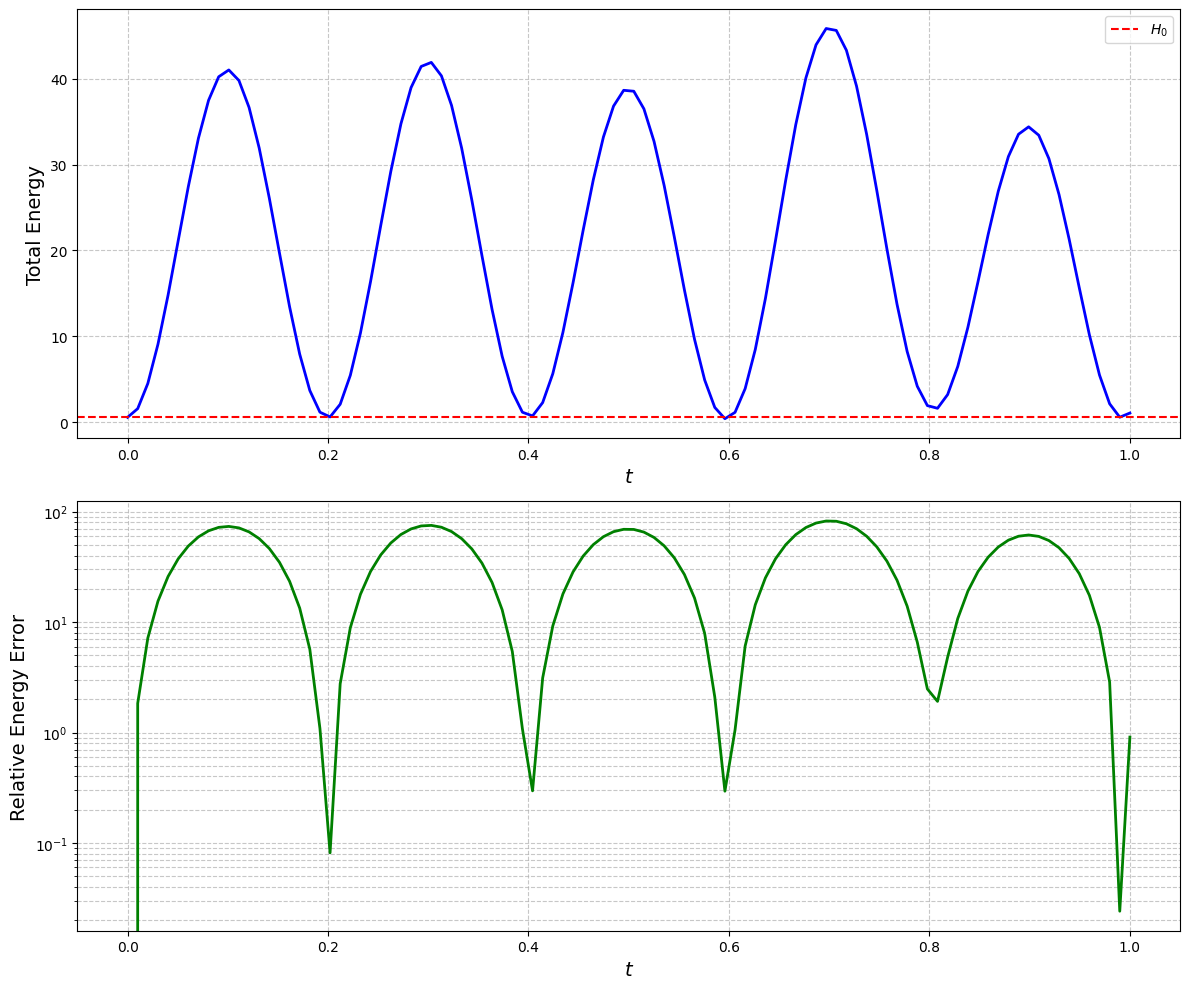

(array([ 0.55000579,  1.56111107,  4.49354789,  9.05517391, 14.79044514,
        21.12613926, 27.42899364, 33.0685907 , 37.4801135 , 40.22084499,
        41.01509857, 39.78244883, 36.64609636, 31.92045504, 26.07923539,
        19.70761967, 13.443613  ,  7.91441391,  3.67414045,  1.1489374 ,
         0.59474212,  2.07190726,  5.43909737, 10.36717438, 16.371621  ,
        22.86033929, 29.19231642, 34.74109979, 38.95723653, 41.42325833,
        41.8956074 , 40.32910641, 36.88138383, 31.89663974, 25.87057374,
        19.40012012, 13.12346543,  7.65629375,  3.53064837,  1.14252338,
         0.71300498,  2.26680388,  5.63021273, 10.44859003, 16.22193513,
        22.35487796, 28.21654686, 33.20427875, 36.8046217 , 38.64572807,
        38.53541923, 36.4810915 , 32.68928432, 27.54531826, 21.57473551,
        15.39069332,  9.63263148,  4.90205116,  1.70235963,  0.388201  ,
         1.12964654,  3.89466232,  8.45140608, 14.39022026, 21.16274134,
        28.13514312, 34.6498198 , 40.09018067, 43.9

In [72]:
draw_energy_conservation_error()

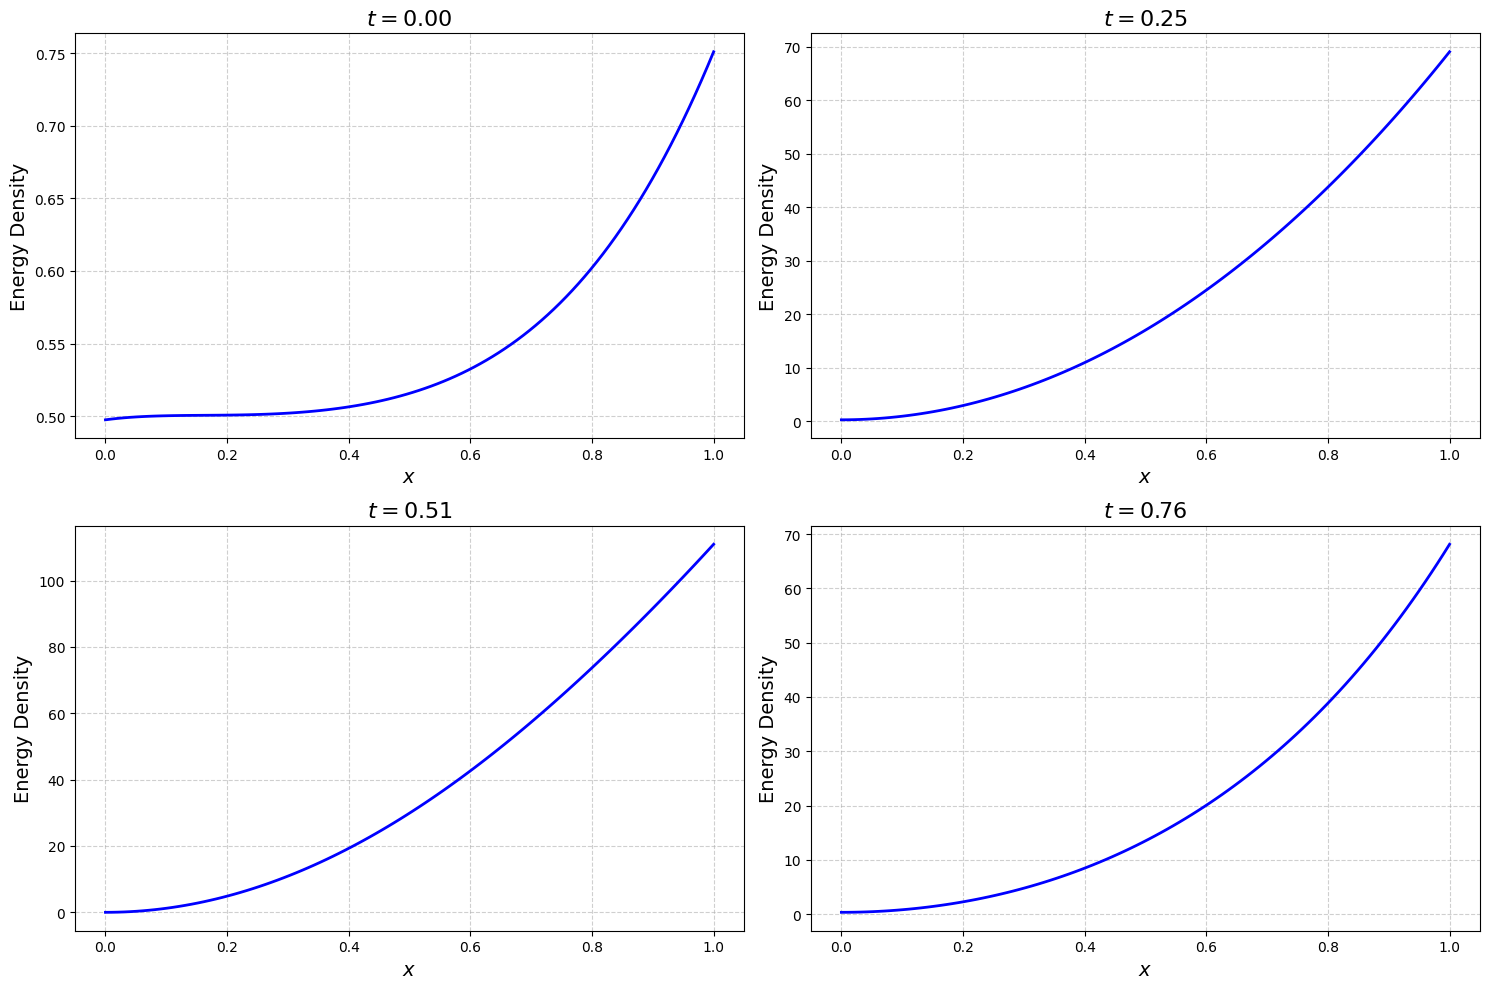

In [73]:
draw_energy_distribution_at_times()

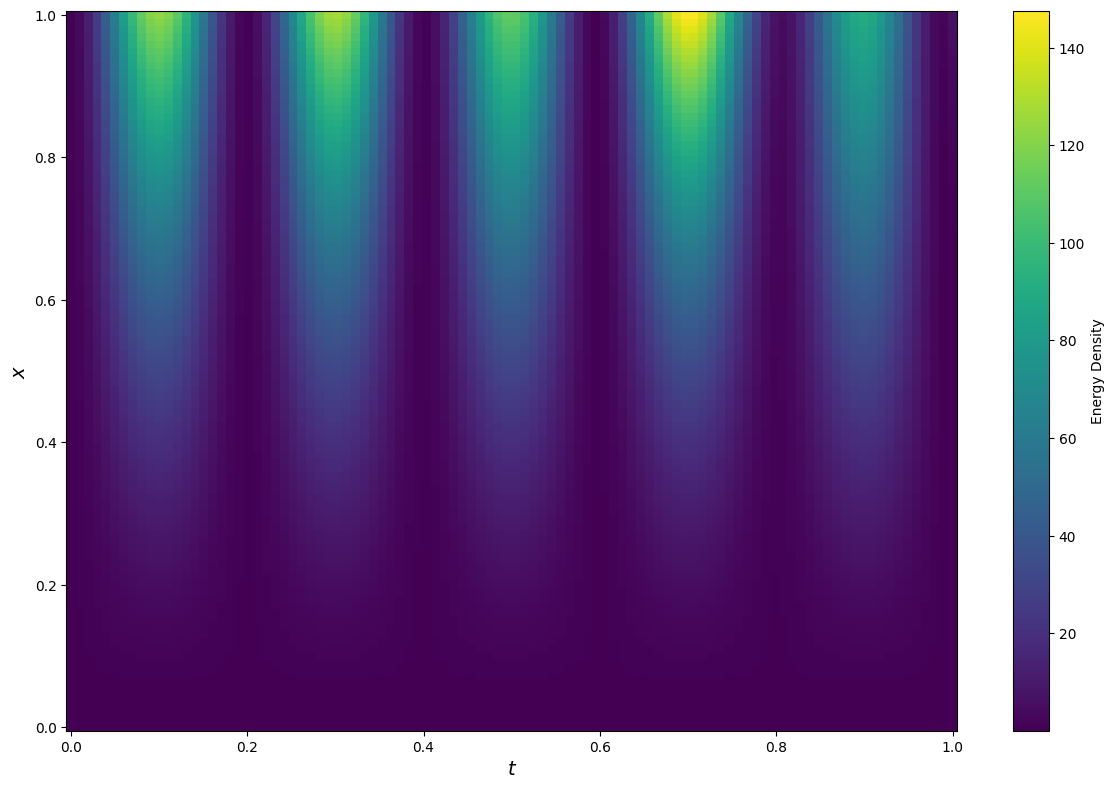

array([[ 0.49741632,  0.48533499,  0.44959807, ...,  0.5045886 ,
         0.55087501,  0.57375753],
       [ 0.49794146,  0.48612744,  0.45122412, ...,  0.49801859,
         0.542373  ,  0.56417251],
       [ 0.49839649,  0.4874728 ,  0.45521995, ...,  0.49433029,
         0.53474742,  0.55459881],
       ...,
       [ 0.7312361 ,  3.65989065, 12.15678787, ...,  3.72830772,
         1.64833248,  5.7101531 ],
       [ 0.74102485,  3.73097754, 12.40463257, ...,  3.7564497 ,
         1.7644974 ,  6.05948019],
       [ 0.75112665,  3.80308819, 12.65550709, ...,  3.78629303,
         1.88719308,  6.42380333]])

In [74]:
draw_energy_density_evolution_heatmap()

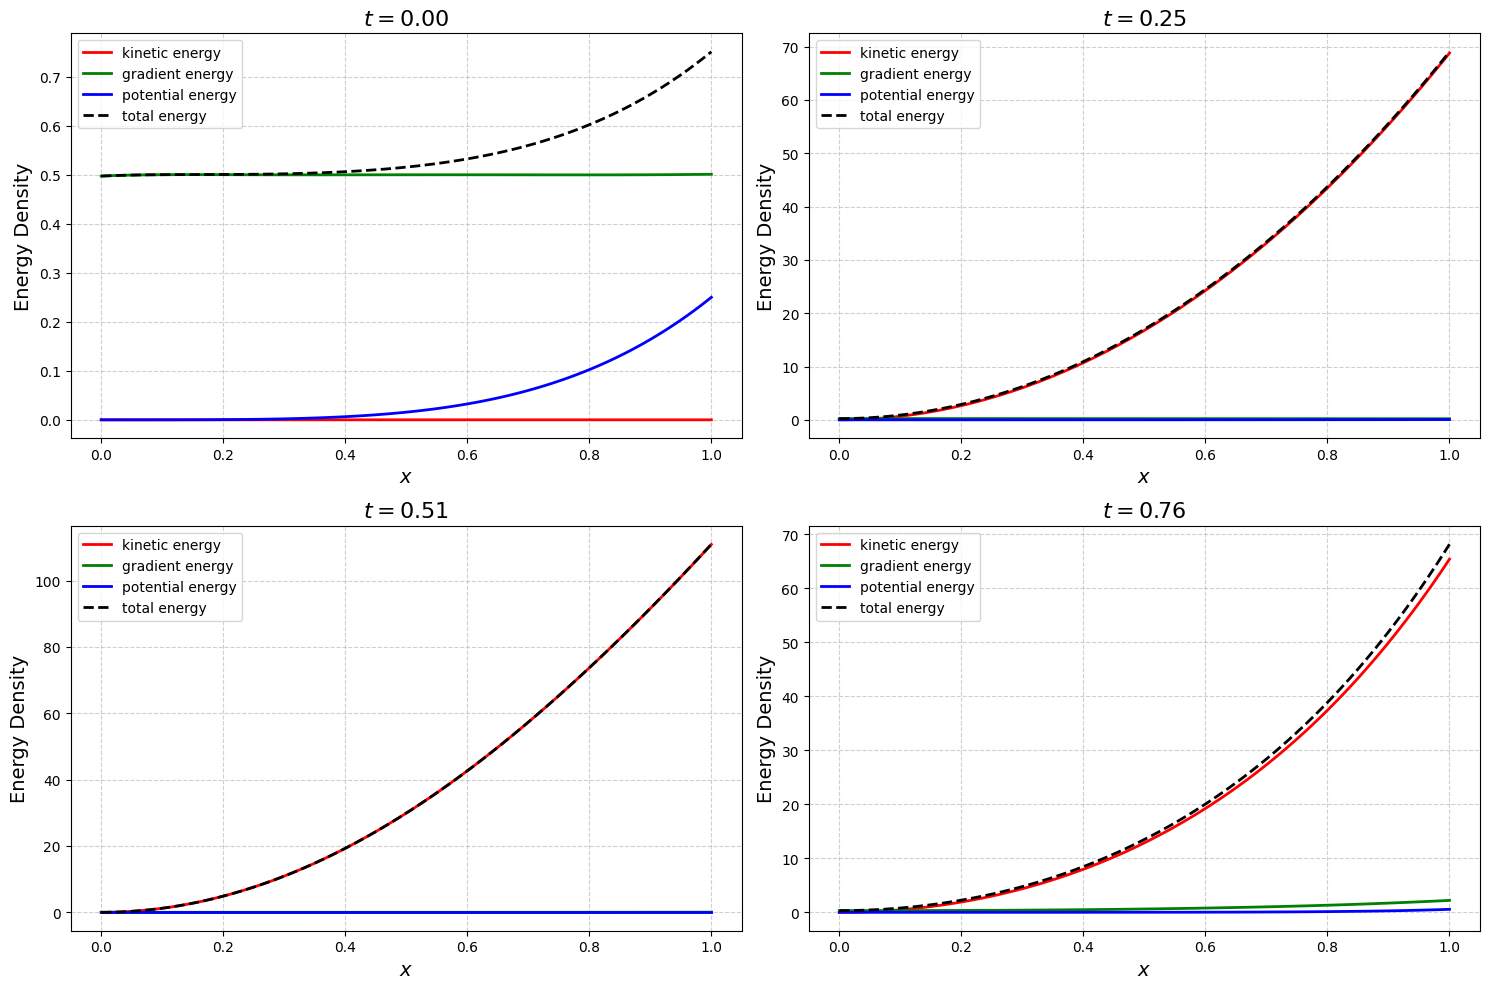

In [75]:
analyze_energy_components()